In [21]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

Download a single file from Majorana Dataset:
- if you want to download more, check out [this website](https://zenodo.org/records/8257027), or simply replace name `MJD_Train_0.hdf5` to `MJD_Train_1.hdf5` ...

In [ ]:
!wget https://zenodo.org/records/8257027/files/MJD_Train_0.hdf5

Define a hdf5 visualization function:

In [25]:
def print_hdf5_structure(name, obj):
    if isinstance(obj, h5py.Group):
        print(f"📁 Group:   {name}")
    elif isinstance(obj, h5py.Dataset):
        print(f"📊 Dataset: {name} | Shape: {obj.shape} | Type: {obj.dtype}")

After downloading the dataset, we will read the data with h5py file, we will first use this to plot the energy spectrum

In [ ]:
with h5py.File("MJD_Train_0.hdf5") as file:
    file.visititems(print_hdf5_structure)
    energy = np.array(file["energy_label"])
    plt.hist(energy,bins=np.linspace(0,4000,1000),histtype="step")
    plt.yscale("log")
    plt.xlabel("Energy [keV]")
    plt.ylabel("Counts")

Then we will try to read out waveforms from this file

In [20]:
with h5py.File("MJD_Train_0.hdf5") as file:
    energy = np.array(file["energy_label"])
    # only selecting higher energy event to make the task easier
    selection_flag = energy > 500
    randind = np.arange(selection_flag.sum())
    np.random.shuffle(randind) #randomize selected waveforms
    data = np.array(file["raw_waveform"])[selection_flag][randind]
    label = np.array(file["psd_label_low_avse"])[selection_flag][randind]
    energy = np.array(file["energy_label"])[selection_flag][randind]
    print(f"data size: {data.shape}")
    print(f"label size: {label.shape}")
    print(f"energy size: {energy.shape}")

data size: (23456, 3800)
label size: (23456,)
energy size: (23456,)


Now we will try to download a single file from the TIDMAD dataset. Assume you have the `download_data.py` file downloaded from the (github repo)[https://github.com/jessicafry/TIDMAD], we can then call this command using the following flags:
- `-t 1` downloading 1 training files
- `-v 0` downloading 0 validation files
- `-s 0` downloading 0 science files
- `-f` force download, do not ask questions

In [ ]:
%run download_data.py -t 1 -v 0 -s 0 -f

📁 Group:   timeseries
📁 Group:   timeseries/channel0001
📊 Dataset: timeseries/channel0001/timeseries | Shape: (2010000000,) | Type: int8
📁 Group:   timeseries/channel0002
📊 Dataset: timeseries/channel0002/timeseries | Shape: (2010000000,) | Type: int8


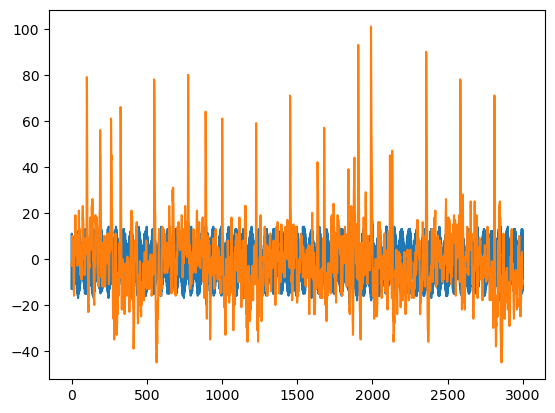

In [31]:
with h5py.File("abra_training_0000.h5") as file:
    file.visititems(print_hdf5_structure)
    injected = np.array(file["timeseries"]["channel0002"]["timeseries"])[:3000]
    noisy = np.array(file["timeseries"]["channel0001"]["timeseries"])[:3000]
    
    plt.plot(injected)
    plt.plot(noisy)